# MAE Reconstruction

In [1]:
!pip install -q transformers torch pillow matplotlib requests

In [2]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import requests
from io import BytesIO
from PIL import Image
from transformers import AutoImageProcessor, ViTMAEForPreTraining

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cpu


## Configuration

In [3]:
MODEL_NAME = "facebook/vit-mae-base" 
MASK_RATIO = 0.75
SEED = 42

In [4]:
processor = AutoImageProcessor.from_pretrained(MODEL_NAME)
model = ViTMAEForPreTraining.from_pretrained(MODEL_NAME)
model.config.mask_ratio = MASK_RATIO
model.to(device)
model.eval()

imagenet_mean = np.array(processor.image_mean)
imagenet_std = np.array(processor.image_std)

print(f"Loaded {MODEL_NAME}")
print(f"Patch size: {model.config.patch_size}, Image size: {model.config.image_size}, Mask ratio: {model.config.mask_ratio}")

preprocessor_config.json:   0%|          | 0.00/217 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/676 [00:00<?, ?B/s]

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


model.safetensors:   0%|          | 0.00/448M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/334 [00:00<?, ?it/s]

Loaded facebook/vit-mae-base
Patch size: 16, Image size: 224, Mask ratio: 0.75


## Helper functions

In [5]:
# 1. original — the input image
# 2. masked — what the encoder actually sees (masked patches blanked out)
# 3. MAE reconstruction — the decoder's output for every patch, including visible ones. These aren't directly supervised during training.
# 4. reconstruction + visible — the reconstruction with the real visible patches pasted back in.

def load_image(source):
    if source.startswith("http://") or source.startswith("https://"):
        response = requests.get(source, headers={"User-Agent": "Mozilla/5.0"})
        return Image.open(BytesIO(response.content)).convert("RGB")
    return Image.open(source).convert("RGB")

# Undo ImageNet normalization and convert to a displayable uint8 array.
def to_uint8(img_tensor):
    img = img_tensor.numpy() * imagenet_std + imagenet_mean
    return np.clip(img * 255, 0, 255).astype(np.uint8)


    # Run one image through MAE: mask, encode, decode, reconstruct.
    # Returns (original, masked, reconstruction, reconstruction_pasted) as uint8 HWC arrays.
    # 
@torch.no_grad()
def run_mae(image, mask_ratio=None, seed=SEED):
    if mask_ratio is not None:
        model.config.mask_ratio = mask_ratio

    torch.manual_seed(seed) 

    pixel_values = processor(images=image, return_tensors="pt").pixel_values.to(device)
    outputs = model(pixel_values)

    # outputs.logits is the decoder's per-patch prediction; unpatchify turns it back into an image
    reconstruction = model.unpatchify(outputs.logits)

    # outputs.mask: 1 = patch was removed (masked), 0 = patch was kept 
    mask = outputs.mask.unsqueeze(-1).repeat(1, 1, model.config.patch_size ** 2 * 3)
    mask = model.unpatchify(mask)

    x = torch.einsum("nchw->nhwc", pixel_values).cpu()
    y = torch.einsum("nchw->nhwc", reconstruction).cpu()
    m = torch.einsum("nchw->nhwc", mask).cpu()

    original = to_uint8(x[0])
    masked = to_uint8(x[0] * (1 - m[0]))
    recon = to_uint8(y[0])
    recon_pasted = to_uint8(x[0] * (1 - m[0]) + y[0] * m[0])

    return original, masked, recon, recon_pasted


def show_result(image_or_path, mask_ratio=None, seed=SEED, title=None):
    image = image_or_path if isinstance(image_or_path, Image.Image) else load_image(image_or_path)
    original, masked, recon, recon_pasted = run_mae(image, mask_ratio=mask_ratio, seed=seed)

    ratio = mask_ratio if mask_ratio is not None else model.config.mask_ratio
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    for ax, img, label in zip(
        axes,
        [original, masked, recon, recon_pasted],
        ["original", f"masked ({ratio:.0%})", "MAE reconstruction", "reconstruction + visible"],
    ):
        ax.imshow(img)
        ax.set_title(label, fontsize=11)
        ax.axis("off")
    if title:
        fig.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()

## Try it on a few sample images

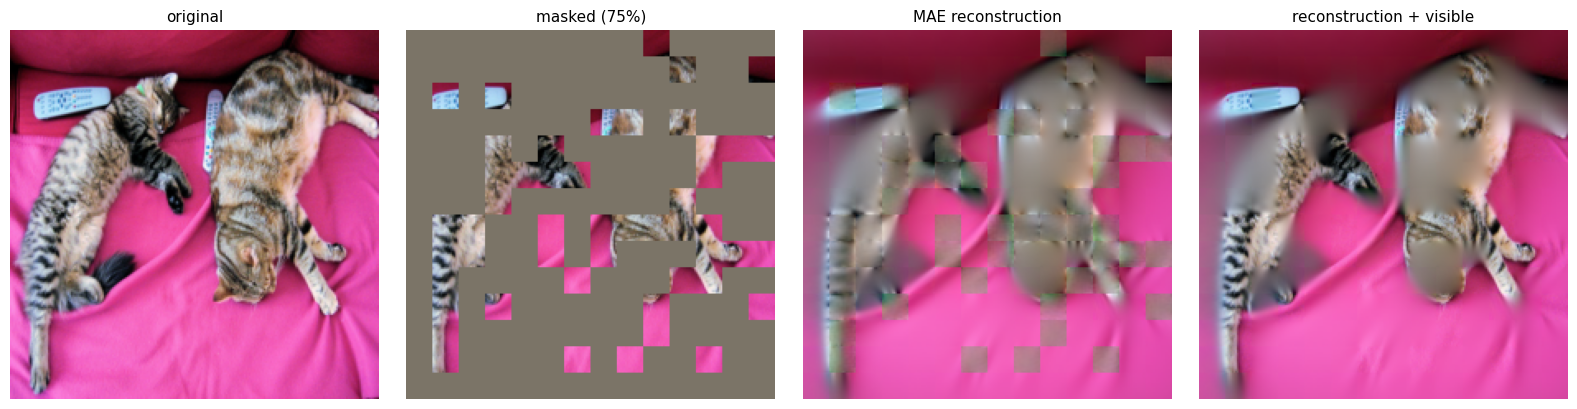

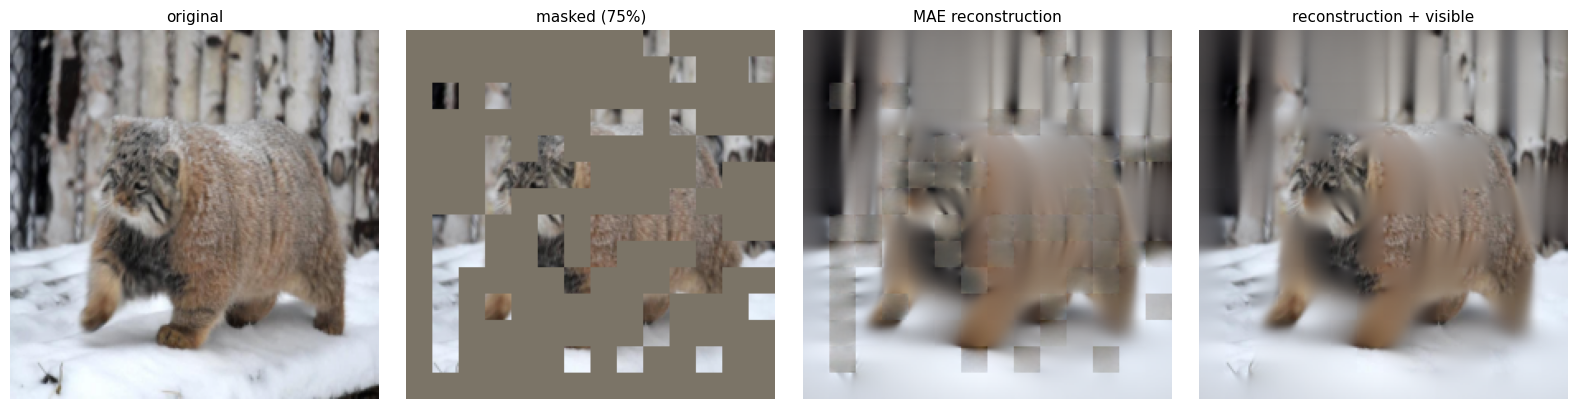

In [6]:
SAMPLE_IMAGES = [
    "http://images.cocodataset.org/val2017/000000039769.jpg",  # two cats on a couch
    "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/pipeline-cat-chonk.jpeg",
]

for url in SAMPLE_IMAGES:
    show_result(url)

## Different masking ratios 

The model was trained at 75%, but the paper shows it still generalizes to other ratios.

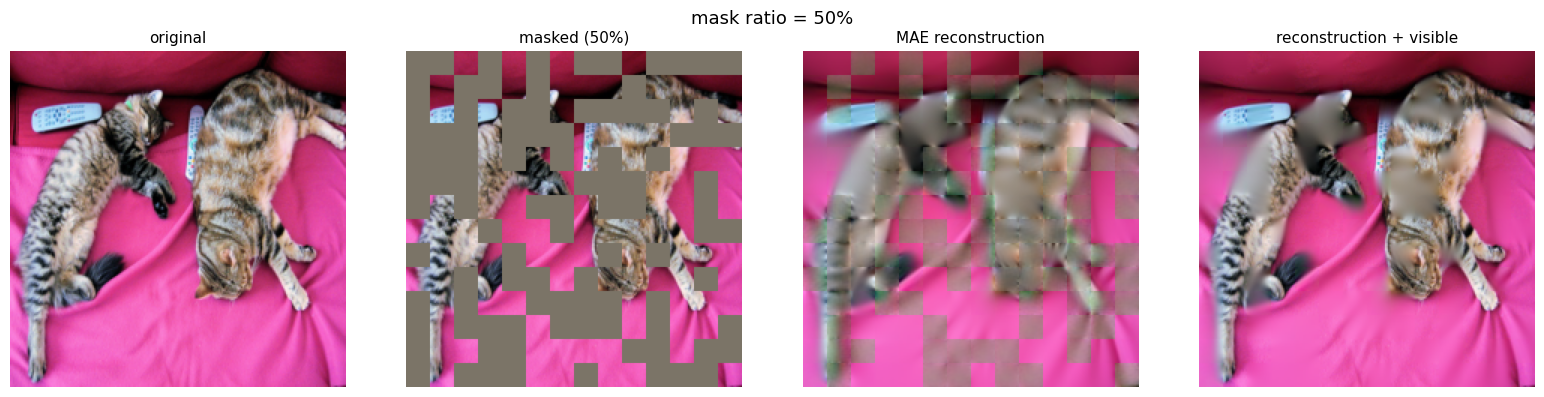

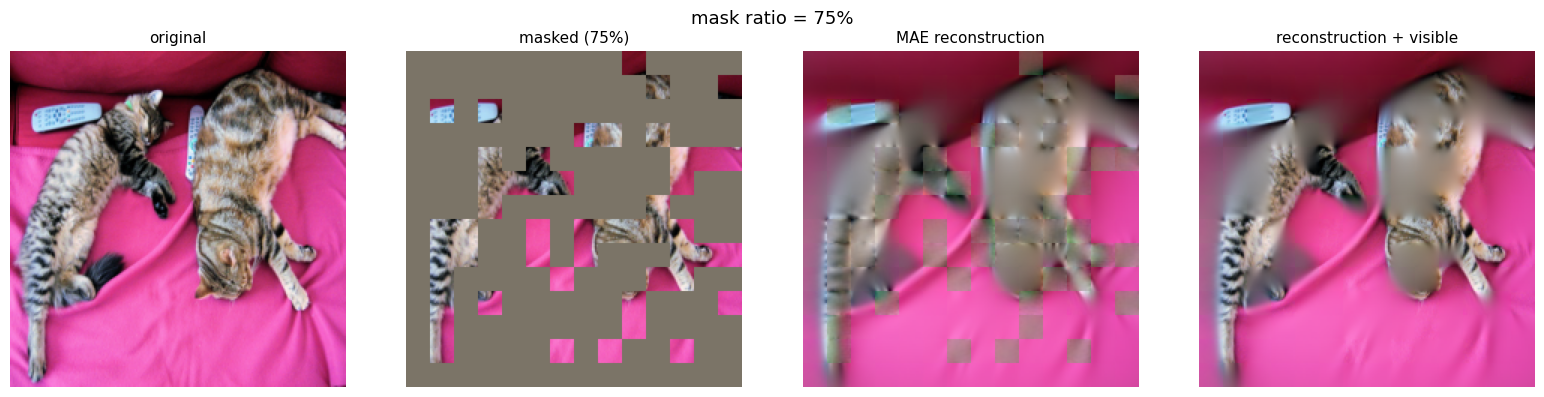

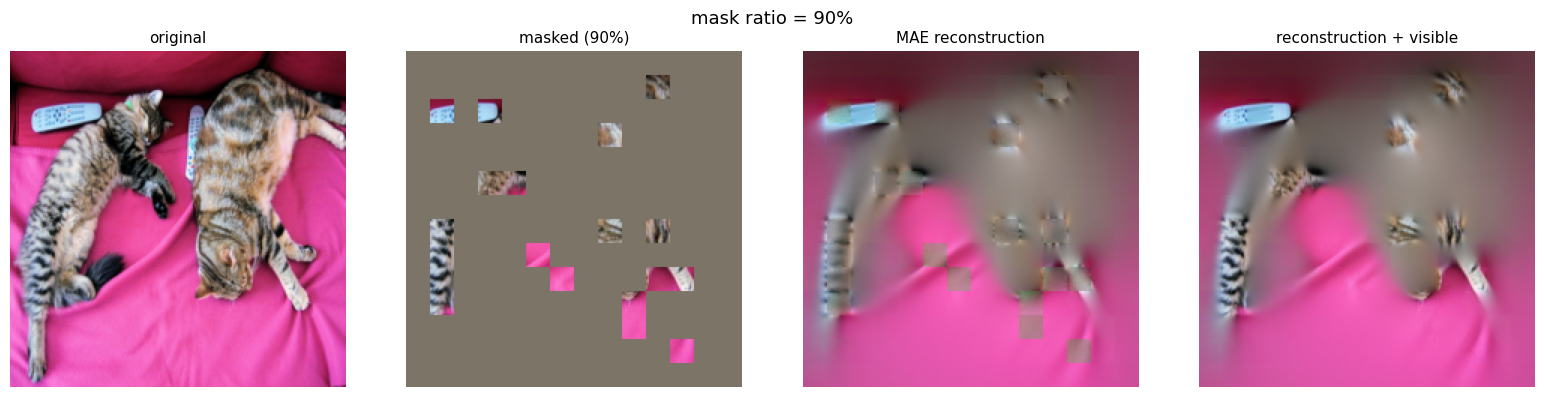

In [8]:
image = load_image(SAMPLE_IMAGES[0])
for ratio in [0.5, 0.75, 0.9]:
    show_result(image, mask_ratio=ratio, title=f"mask ratio = {ratio:.0%}")